<a href="https://colab.research.google.com/github/arauch6363-crypto/PT2026/blob/main/pmu_winner_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Galopp-Siegvorhersage (PMU) – ML-Pipeline mit leakage-sicherem Feature Engineering & P&L-Backtest

**Ziel:** Für jedes Rennen die Siegwahrscheinlichkeit jedes Starters schätzen und daraus zwei Wettstrategien
(1 € Flat-Stake) ableiten:

1. **Top-Pick** – in jedem Rennen auf das Pferd mit der höchsten Modellwahrscheinlichkeit
2. **Value** – nur wetten, wenn *Modellwahrscheinlichkeit × Quote* deutlich über 1 liegt

**Datenquelle:** Ordner `parquet/` mit je einer Datei pro Renntag und Tabelle
(`pmu_races`, `pmu_runners`, `tracking_runners`, `tracking_sections`, `tracking_leader`, …).
Genutzt werden `pmu_races`, `pmu_runners`, `tracking_runners` und `tracking_sections`; weitere Tabellen werden geladen
und im Überblick angezeigt. Zum Testen ohne echte Daten erzeugt `make_sample_data.py` synthetische Daten im selben Schema.

**Benötigte Pakete:** `pandas pyarrow numpy scikit-learn lightgbm scipy matplotlib` (in Colab alle vorinstalliert).

## Leakage-Grundsätze (gelten für das ganze Notebook)

| Information | Wann bekannt? | Verwendung |
|---|---|---|
| Programm: Alter, Gewicht, Box (draw), Rating, Jockey, Trainer, Scheuklappen, Distanz, Boden, Kategorie, Preisgeld | **vor** dem Rennen | direktes Feature |
| `form` (Musique), `starts/wins/places/earnings` | laut PMU vor dem Rennen – **wird unten automatisch geprüft** | direktes Feature (nur wenn Prüfung besteht) |
| `odds_morning` | vor dem Rennen | Markt-Feature / Entscheidungsquote |
| `odds_final` (PMU-Endquote) | erst beim Start | **nur zur Abrechnung** + als Historie früherer Rennen |
| `finish_pos`, `lengths_behind`, `incident`, `finish_order` | nach dem Rennen | **Target** bzw. nur als Historie früherer Rennen |
| Alle `tracking_*`-Tabellen (Zeiten, Speeds, Positionen) | nach dem Rennen | **nur als Historie früherer Rennen** |

Technisch wird das durch drei Dinge abgesichert:
* Alle Historien-Features werden per `merge_asof(..., allow_exact_matches=False)` gebildet → nur Daten mit **Datum < Renndatum**.
* Zeitlicher Split Train → Validation → Test (kein Shuffle), Test-Periode wird erst ganz am Ende angefasst.
* Automatische Leak-Tests: Zeitreise-Test (Daten nach Tag D löschen → Features am Tag D müssen identisch bleiben), Label-Shuffle-Test, Spalten-Blacklist.

## 0 · Setup & Konfiguration

In [ ]:
import re
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 200)
RNG = np.random.default_rng(7)

# --- Pfad zu den Daten --------------------------------------------------------
from google.colab import drive; drive.mount('/content/drive')
DATA_DIR = Path('/content/drive/MyDrive/PT_tracking/parquet')  # Ordner mit Unterordnern pmu_races/, pmu_runners/, …
# Test ohne echte Daten:  python make_sample_data.py --out sample_parquet   ->  DATA_DIR = Path("sample_parquet")

# --- Zeitlicher Split (None = automatisch 60 % / 20 % / 20 % der Renntage) ---
TRAIN_END = None                    # z. B. "2026-06-30"  (inklusive)
VALID_END = None                    # z. B. "2026-08-15"  (inklusive) – danach Test
MIN_HISTORY_DAYS = 21               # erste Tage nur als "Aufwärm-Historie", nicht zum Training
KEEP_DISCIPLINES = None             # z. B. ["PLAT"] – None = alle Disziplinen behalten

# --- Wetten -------------------------------------------------------------------
STAKE = 1.0                         # Flat-Stake in €
DECISION_ODDS = "odds_morning"      # Quote, die zum Entscheidungszeitpunkt bekannt ist (konservativ)
SETTLE_ODDS = "odds_final"          # PMU zahlt die Endquote aus (Pari-Mutuel)
MIN_BETS_FOR_SELECTION = 40         # Mindestanzahl Wetten, damit eine Value-Regel auf Validation gewählt werden darf

# Vorab festgelegte Value-Regel für den Walk-Forward-Test (wird NICHT an Ergebnissen optimiert)
WF_RULE = dict(min_edge=0.10, min_p=0.05, max_odds=25.0)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1 · Daten laden
Jede Tabelle liegt als `<tabelle>/<YYYYMMDD>.parquet` vor. Wir hängen das Dateidatum als Spalte `file_date` an
(dient auch als Plausibilitätsprüfung gegen das Datum in der `race_id`).

In [ ]:
def load_table(name: str) -> pd.DataFrame:
    files = sorted((DATA_DIR / name).glob("*.parquet"))
    parts = []
    for f in files:
        try:
            d = pd.read_parquet(f)
        except Exception as e:                       # defekte Datei → melden, überspringen
            print(f"  ! {f} nicht lesbar: {e}")
            continue
        if len(d):
            d["file_date"] = pd.to_datetime(f.stem, format="%Y%m%d", errors="coerce")
            parts.append(d)
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()


tables = {p.name: load_table(p.name) for p in sorted(DATA_DIR.iterdir()) if p.is_dir()}
overview = pd.DataFrame({
    "rows": {k: len(v) for k, v in tables.items()},
    "cols": {k: v.shape[1] for k, v in tables.items()},
    "days": {k: v["file_date"].nunique() if len(v) else 0 for k, v in tables.items()},
})
overview

,rows,cols,days
fehler,0,0,0
pmu_races,5259,23,456
pmu_runners,59642,30,456
tracking_leader,26448,7,435
tracking_obstacles,0,0,0
tracking_races,4461,29,435
tracking_runners,51077,54,435
tracking_sections,451482,14,435
tracking_status,5259,13,456


In [ ]:
for req in ["pmu_races", "pmu_runners"]:
    assert req in tables and len(tables[req]), f"Pflicht-Tabelle {req} fehlt"
races_raw = tables["pmu_races"].copy()
runners_raw = tables["pmu_runners"].copy()
trk_runners_raw = tables.get("tracking_runners", pd.DataFrame()).copy()
trk_sections_raw = tables.get("tracking_sections", pd.DataFrame()).copy()
print(races_raw.dtypes.to_string())
runners_raw.head(3)

race_id                     object
date                        object
hippodrome                  object
pmu_code                    object
reunion                      int64
race_no                      int64
race_name                   object
post_time                   object
discipline                  object
specialite                  object
statut                      object
distance_m                   int64
corde                       object
parcours                    object
prize_eur                    int64
categorie                   object
conditions_age              object
conditions_sexe             object
going                       object
going_value                 object
runners_declared             int64
finish_order                object
file_date           datetime64[ns]


,race_id,saddle_no,horse,status,age,sex,jockey,trainer,owner,breeder,draw,weight_kg,rating,blinkers,form,starts,wins,places,earnings_eur,sire,dam,odds_final,odds_morning,finish_pos,dist_prev_label,incident,comment,lengths_prev,lengths_behind,file_date
0,20250614R4C1,1,HAYZUM,PARTANT,2,MALES,A.MADAMET,H.GHABRI,H.GHABRI,RATHASKER STUD,6,58.0,NaN,SANS_OEILLERES,3p5p6p,3,0,3,6300.0,BUNGLE INTHEJUNGLE,TELL THE WIND,8.2,9.5,5.0,3 L 1/2,None,None,3.5,7.25,2025-06-14
1,20250614R4C1,2,GO KEN GO,PARTANT,2,MALES,H.JOURNIAC,F.GUYADER (S),MME A.MARNANE/MME O.MARNANE,MR JULIEN MOUTEL,2,58.0,NaN,SANS_OEILLERES,5p6p,2,0,2,2100.0,GOKEN,DIVA MORITA,25.0,20.0,2.0,1 L,None,None,1.0,1.00,2025-06-14
2,20250614R4C1,3,KAILANI,PARTANT,2,MALES,A.POUCHIN,S.WATTEL (S),PD.SAVILL,MR PETER-DAVID SAVILL,1,58.0,NaN,SANS_OEILLERES,4p,1,0,1,2400.0,GOKEN,DIZZY BIZU,6.4,5.6,1.0,None,None,None,NaN,0.00,2025-06-14


## 2 · Data Cleaning

### 2.1 Hilfsfunktionen zur Normalisierung
Namen kommen in unterschiedlicher Schreibweise vor (`I.MENDIZABAL` vs. `I. MENDIZABAL`, Suffix `(S)` bei Trainern …).

In [ ]:
def norm_name(s: pd.Series) -> pd.Series:
    s = s.astype("string").str.upper().str.strip()
    s = s.str.replace(r"\s*\(S\)\s*$", "", regex=True)          # "(S)" = Sous-traitance-Kennzeichen
    s = s.str.replace(r"\.\s+", ".", regex=True)                  # "I. MENDIZABAL" -> "I.MENDIZABAL"
    s = s.str.replace(r"\s+", " ", regex=True)
    return s


def to_float(s: pd.Series) -> pd.Series:
    """'3,9' -> 3.9 ; leere Strings -> NaN"""
    return pd.to_numeric(s.astype("string").str.replace(",", ".", regex=False).str.strip(), errors="coerce")

### 2.2 Rennen (`pmu_races`)

In [ ]:
races = races_raw.drop_duplicates("race_id", keep="last").copy()
races["date"] = pd.to_datetime(races["race_id"].str[:8], format="%Y%m%d")
bad_date = (races["date"] != races["file_date"]).sum()
print("Rennen mit abweichendem Dateidatum:", bad_date)
races["going_value"] = to_float(races["going_value"])
races["distance_m"] = pd.to_numeric(races["distance_m"], errors="coerce")
races["prize_eur"] = pd.to_numeric(races["prize_eur"], errors="coerce")
races["post_dt"] = pd.to_datetime(races["date"].dt.strftime("%Y-%m-%d") + " " + races["post_time"].astype("string"),
                                  errors="coerce")
races["is_psf"] = races["going"].astype("string").str.contains("PSF", case=False, na=False).astype(int)  # Polytrack
races["dist_bucket"] = pd.cut(races["distance_m"], [0, 1300, 1700, 2100, 2600, 5000],
                              labels=["sprint", "mile", "inter", "long", "stayer"]).astype("string")
for c in ["hippodrome", "pmu_code", "discipline", "specialite", "corde", "categorie",
          "conditions_age", "conditions_sexe", "going"]:
    if c in races:
        races[c] = races[c].astype("string").str.upper().str.strip()
print(races["discipline"].value_counts(dropna=False).to_string())
if KEEP_DISCIPLINES:
    races = races[races["discipline"].isin([d.upper() for d in KEEP_DISCIPLINES])]
    print("nach Disziplin-Filter:", len(races), "Rennen")
print(races["statut"].value_counts(dropna=False).to_string())
races.describe(include="number").T[["count", "mean", "min", "max"]]

Rennen mit abweichendem Dateidatum: 0
discipline
PLAT    5259
statut
ARRIVEE_DEFINITIVE_COMPLETE    3340
FIN_COURSE                     1907
PROGRAMMEE                       12


,count,mean,min,max
reunion,5259.0,3.016923,1.0,15.0
race_no,5259.0,4.591557,1.0,12.0
distance_m,5259.0,1900.874691,800.0,4000.0
prize_eur,5259.0,28370.051341,6000.0,5000000.0
going_value,4003.0,3.570747,2.3,5.6
runners_declared,5259.0,11.340939,3.0,20.0
is_psf,5259.0,0.236357,0.0,1.0


### 2.3 Starter (`pmu_runners`)

In [ ]:
POST_RACE_COLS = {  # Spalten, die ERST NACH dem Rennen feststehen -> niemals direkte Features
    "odds_final", "finish_pos", "dist_prev_label", "incident", "comment", "lengths_prev", "lengths_behind",
    "finish_order", "statut", "won", "placed",
}

run = runners_raw.copy()
n0 = len(run)
run = run.drop_duplicates(["race_id", "saddle_no"], keep="last")
print(f"Duplikate entfernt: {n0 - len(run)}")

for c in ["horse", "jockey", "trainer", "owner", "breeder", "sire", "dam"]:
    run[c + "_key"] = norm_name(run[c])
# Homonyme vermeiden: Pferdename + Vater
run["horse_id"] = run["horse_key"].fillna("?") + "|" + run["sire_key"].fillna("?")

for c in ["odds_final", "odds_morning", "weight_kg", "rating", "earnings_eur", "finish_pos", "lengths_behind"]:
    run[c] = pd.to_numeric(run[c], errors="coerce")
# unplausible Quoten entfernen
for c in ["odds_final", "odds_morning"]:
    run.loc[(run[c] < 1.01) | (run[c] > 1000), c] = np.nan

run["is_runner"] = (run["status"].astype("string").str.upper() == "PARTANT") & \
                   (run["incident"].astype("string").str.upper().fillna("") != "NON_PARTANT")
print(run["status"].value_counts(dropna=False).to_string())
print("Incidents:", run["incident"].value_counts(dropna=False).to_dict())

# Nicht-Starter komplett entfernen (sie verändern das Feld und sind nicht wettbar)
run = run[run["is_runner"]].copy()

# Renndaten anhängen
run = run.merge(races[["race_id", "date", "post_dt", "hippodrome", "pmu_code", "distance_m", "dist_bucket",
                       "going_value", "is_psf", "corde", "categorie", "prize_eur", "discipline", "statut"]],
                on="race_id", how="left", validate="many_to_one")
missing_race = run["date"].isna().sum()
print("Starter ohne Renn-Stammdaten (entfernt):", missing_race)
run = run[run["date"].notna()].copy()

# Feldgröße nach Abzug der Nicht-Starter
run["n_runners"] = run.groupby("race_id")["saddle_no"].transform("size")

# Ziel & Ergebnis-Flags (nur für Target / Historie!)
run["won"] = (run["finish_pos"] == 1).astype(int)
run["placed"] = (run["finish_pos"] <= 3).astype(int)
run["finished"] = run["finish_pos"].notna().astype(int)

Duplikate entfernt: 0
status
PARTANT        57655
NON_PARTANT     1987
Incidents: {None: 57479, 'NON_PARTANT': 1978, 'ARRETE': 81, 'TOMBE': 59, 'DISTANCE': 27, 'RESTE_AU_POTEAU': 15, 'DEROBE': 3}
Starter ohne Renn-Stammdaten (entfernt): 0


### 2.4 Plausibilitätsregeln pro Rennen
* Rennen **mit Ergebnis** = mindestens ein Starter hat `finish_pos`
* genau **ein** Sieger (Dead Heats werden für Training und P&L ausgeschlossen – Auszahlung wäre geteilt)
* mindestens 4 Starter
* Positionen innerhalb des Rennens eindeutig

In [ ]:
g = run.groupby("race_id")
race_q = pd.DataFrame({
    "has_result": g["finished"].sum() > 0,
    "n_winners": g["won"].sum(),
    "n_runners": g["saddle_no"].size(),
    "dup_pos": g["finish_pos"].apply(lambda s: s.dropna().duplicated().any()),
    "odds_cov": g["odds_final"].apply(lambda s: s.notna().mean()),
})
race_q["valid_train"] = race_q.has_result & (race_q.n_winners == 1) & (race_q.n_runners >= 4) & ~race_q.dup_pos
print(race_q[["has_result", "valid_train"]].mean().round(3).to_dict())
print("Dead Heats / kein Sieger:", (race_q.has_result & (race_q.n_winners != 1)).sum())
run = run.merge(race_q[["has_result", "valid_train"]], left_on="race_id", right_index=True, how="left")

# Overround (Buchmacher-/PMU-Marge) als Sanity-Check
ovr = run.groupby("race_id")["odds_final"].apply(lambda s: (1 / s).sum())
print(f"Overround Endquoten: Median {ovr.median():.3f}  (≈ {100*(1-1/ovr.median()):.1f}% Abzug)")

{'has_result': 0.998, 'valid_train': 0.963}
Dead Heats / kein Sieger: 10
Overround Endquoten: Median 1.187  (≈ 15.8% Abzug)


### 2.5 Tracking-Daten (nur als Historie!)
Verknüpfung über `race_id + saddle_no` (robuster als Namen).
Daraus bilden wir **pro Lauf** leistungsbeschreibende Kennzahlen, die *relativ zum Feld* normiert werden
(dadurch weitgehend unabhängig von Distanz, Boden und Bahn):

* `speed_rel` – Ø-Geschwindigkeit minus Median des Feldes
* `last400_rel`, `last600_rel` – Endspeed vs. Feld
* `finish_index_rel`, `behind_winner_s`
* `early_pos_pct` – Position im ersten Abschnitt (Laufstil: Führungspferd vs. Verfolger)
* aus `tracking_sections`: `early_speed_rel`, `late_speed_rel`, `sectional_kick` (Beschleunigung am Ende)

In [ ]:
def build_run_perf(trk: pd.DataFrame, secs: pd.DataFrame, races: pd.DataFrame) -> pd.DataFrame:
    if trk.empty:
        return pd.DataFrame(columns=["race_id", "saddle_no"])
    t = trk.drop_duplicates(["race_id", "saddle_no"], keep="last").copy()
    num = ["avg_speed_kmh", "speed_last400_kmh", "speed_last600_kmh", "last600_s", "finish_index", "behind_winner_s",
           "vmax_kmh", "pos_gain_800_finish", "T1_pos", "official_time_s", "stride_len_mid_m", "stride_change_pct"]
    for c in num:
        t[c] = pd.to_numeric(t.get(c), errors="coerce")
    # Ausreißer/Messfehler: Geschwindigkeiten außerhalb 30–75 km/h verwerfen
    for c in ["avg_speed_kmh", "speed_last400_kmh", "speed_last600_kmh", "vmax_kmh"]:
        t.loc[(t[c] < 30) | (t[c] > 75), c] = np.nan
    t = t[t["status"].astype("string").str.startswith("gelaufen", na=False)]
    gg = t.groupby("race_id")
    t["n_trk"] = gg["saddle_no"].transform("size")
    t["speed_rel"] = t["avg_speed_kmh"] - gg["avg_speed_kmh"].transform("median")
    t["last400_rel"] = t["speed_last400_kmh"] - gg["speed_last400_kmh"].transform("median")
    t["last600_rel"] = gg["last600_s"].transform("median") - t["last600_s"]          # >0 = schneller als Feld
    t["finish_index_rel"] = t["finish_index"] - gg["finish_index"].transform("median")
    t["early_pos_pct"] = (t["T1_pos"] - 1) / (t["n_trk"] - 1).clip(lower=1)
    keep = ["race_id", "saddle_no", "avg_speed_kmh", "speed_rel", "last400_rel", "last600_rel", "finish_index_rel",
            "behind_winner_s", "early_pos_pct", "pos_gain_800_finish", "vmax_kmh", "stride_change_pct"]
    out = t[keep]

    if not secs.empty:
        s = secs.copy()
        for c in ["m_to_go", "speed_kmh", "position", "seg_len_m"]:
            s[c] = pd.to_numeric(s[c], errors="coerce")
        s.loc[(s["speed_kmh"] < 25) | (s["speed_kmh"] > 80), "speed_kmh"] = np.nan
        s = s.merge(races[["race_id", "distance_m"]], on="race_id", how="left")
        s["phase"] = np.where(s["m_to_go"] < 400, "late", np.where(s["m_to_go"] >= 0.5 * s["distance_m"], "early", "mid"))
        agg = s.pivot_table(index=["race_id", "saddle_no"], columns="phase", values="speed_kmh", aggfunc="mean")
        agg.columns = [f"sec_{c}_speed" for c in agg.columns]
        agg = agg.reset_index()
        for c in ["sec_early_speed", "sec_late_speed"]:
            if c not in agg:
                agg[c] = np.nan
        ga = agg.groupby("race_id")
        agg["early_speed_rel"] = agg["sec_early_speed"] - ga["sec_early_speed"].transform("median")
        agg["late_speed_rel"] = agg["sec_late_speed"] - ga["sec_late_speed"].transform("median")
        agg["sectional_kick"] = agg["sec_late_speed"] - agg["sec_early_speed"]
        out = out.merge(agg[["race_id", "saddle_no", "early_speed_rel", "late_speed_rel", "sectional_kick"]],
                        on=["race_id", "saddle_no"], how="outer")
    return out


run_perf = build_run_perf(trk_runners_raw, trk_sections_raw, races)
print("Läufe mit Tracking:", len(run_perf), "| Abdeckung:",
      round(run.merge(run_perf[["race_id", "saddle_no"]], on=["race_id", "saddle_no"]).shape[0] / max(len(run), 1), 3))
run_perf.describe().T[["count", "mean", "std", "min", "max"]]

Läufe mit Tracking: 49221 | Abdeckung: 0.854


,count,mean,std,min,max
saddle_no,49221.0,6.679974,3.977351,1.000000,20.000000
avg_speed_kmh,49056.0,56.683309,2.666437,30.400000,75.000000
speed_rel,49056.0,-0.138461,0.887918,-27.970000,29.490000
last400_rel,48709.0,-0.550419,2.635875,-30.115000,17.110000
last600_rel,48663.0,-0.356581,3.153324,-435.265000,35.575000
finish_index_rel,48773.0,-0.557405,27.129055,-201.250000,4376.100000
behind_winner_s,49157.0,1.487930,6.540533,0.000000,436.000000
early_pos_pct,48718.0,0.500041,0.318697,-0.166667,4.000000
pos_gain_800_finish,48534.0,-0.025425,4.650788,-38.000000,17.000000
vmax_kmh,48712.0,64.124313,2.932320,49.000000,74.990000


In [ ]:
PLAUSIBLE = {"speed_rel": (-5, 5), "last400_rel": (-10, 10), "last600_rel": (-6, 6),
             "finish_index_rel": (-30, 30), "behind_winner_s": (0, 20), "early_pos_pct": (0, 1),
             "early_speed_rel": (-5, 5), "late_speed_rel": (-10, 10), "sectional_kick": (-10, 15),
             "stride_change_pct": (-40, 40), "pos_gain_800_finish": (-15, 15)}
for c, (lo, hi) in PLAUSIBLE.items():
    if c in run_perf:
        n_bad = (~run_perf[c].between(lo, hi) & run_perf[c].notna()).sum()
        run_perf[c] = run_perf[c].where(run_perf[c].between(lo, hi))   # Ausreißer -> NaN
        print(f"{c:22s} {n_bad:5d} Ausreißer entfernt")

speed_rel                188 Ausreißer entfernt
last400_rel              622 Ausreißer entfernt
last600_rel              726 Ausreißer entfernt
finish_index_rel          87 Ausreißer entfernt
behind_winner_s          165 Ausreißer entfernt
early_pos_pct            227 Ausreißer entfernt
early_speed_rel          213 Ausreißer entfernt
late_speed_rel           581 Ausreißer entfernt
sectional_kick          1087 Ausreißer entfernt
stride_change_pct       1279 Ausreißer entfernt
pos_gain_800_finish       46 Ausreißer entfernt


### 2.6 Leak-Check: Sind `form`, `starts`, `wins`, … wirklich *vor* dem Rennen erhoben?

PMU liefert diese Felder im Programm (vor dem Rennen). Falls die Daten aber nach dem Rennen gescrapt wurden,
könnten sie das Ergebnis des aktuellen Rennens schon enthalten → massives Leakage. Test anhand aufeinanderfolgender
Läufe desselben Pferdes (nur Paare mit `starts`-Differenz = 1, also kein unbekannter Lauf dazwischen) und nur
**Sieger-Läufe** (die informativen Fälle):

* **Vor-Rennen-Hypothese:** `wins(nächster Lauf) − wins(dieser Lauf) = 1`
* **Nach-Rennen-Hypothese:** `wins(dieser Lauf) − wins(vorheriger Lauf) = 1`

Analog für die Musique: Entspricht das erste Zeichen dem **aktuellen** Ergebnis (Leak) oder dem **vorherigen**?

In [ ]:
def parse_musique(s) -> list:
    """'2p2p(25)3p0pDp' -> [2, 2, 3, 10, 11]  (neueste zuerst; 0 = 10.+, Buchstabe = nicht im Ziel)"""
    if s is None or (isinstance(s, float) and np.isnan(s)) or pd.isna(s):
        return []
    s = re.sub(r"\(\d+\)", "", str(s))
    out = []
    for pos, _disc in re.findall(r"(\d|[A-Z])([a-z])", s):
        out.append(10 if pos == "0" else (int(pos) if pos.isdigit() else 11))
    return out


def check_prerace_fields(run: pd.DataFrame) -> dict:
    d = run[run["has_result"]].sort_values(["horse_id", "date", "post_dt"]).copy()
    g = d.groupby("horse_id")
    d["nxt_starts"], d["nxt_wins"] = g["starts"].shift(-1), g["wins"].shift(-1)
    d["prv_starts"], d["prv_wins"] = g["starts"].shift(1), g["wins"].shift(1)
    d["prv_pos"] = g["finish_pos"].shift(1)
    w = d[d["won"] == 1]
    pre = w.loc[(w.nxt_starts - w.starts) == 1].eval("nxt_wins - wins == 1").mean()
    post = w.loc[(w.starts - w.prv_starts) == 1].eval("wins - prv_wins == 1").mean()
    first = d["form"].map(lambda s: (parse_musique(s) or [np.nan])[0])
    clip = lambda x: np.where(x > 9, 10, x)
    f_cur = (first == clip(d["finish_pos"])).mean()
    f_prev = (first == clip(d["prv_pos"]))[d["prv_pos"].notna()].mean()
    return {"wins_pre_race_hypothesis": pre, "wins_post_race_hypothesis": post,
            "form_matches_current_result": f_cur, "form_matches_previous_result": f_prev}


chk = check_prerace_fields(run)
print({k: round(float(v), 3) for k, v in chk.items()})
CAREER_PRE_RACE = not (chk["wins_post_race_hypothesis"] > chk["wins_pre_race_hypothesis"] + 0.2)
FORM_PRE_RACE = not (chk["form_matches_current_result"] > chk["form_matches_previous_result"] + 0.2)
print("Karriere-Stats vor dem Rennen erhoben:", CAREER_PRE_RACE, "| Musique vor dem Rennen:", FORM_PRE_RACE)
if not (CAREER_PRE_RACE and FORM_PRE_RACE):
    print("⚠️  Felder enthalten vermutlich das aktuelle Ergebnis -> es werden die Werte des VORHERIGEN Laufs verwendet.")

{'wins_pre_race_hypothesis': 0.999, 'wins_post_race_hypothesis': 0.146, 'form_matches_current_result': 0.144, 'form_matches_previous_result': 0.951}
Karriere-Stats vor dem Rennen erhoben: True | Musique vor dem Rennen: True


## 3 · Feature Engineering (strikt nur Vergangenheit)

### 3.1 Historie pro Lauf
`hist` enthält pro abgeschlossenem Lauf die *nach* dem Rennen bekannten Leistungswerte. Sie werden später
ausschließlich über `merge_asof(..., allow_exact_matches=False)` an **spätere** Renntage angehängt.

In [ ]:
def make_hist(run: pd.DataFrame, run_perf: pd.DataFrame) -> pd.DataFrame:
    h = run[run["has_result"]].copy()
    h["pos_pct"] = ((h["finish_pos"] - 1) / (h["n_runners"] - 1).clip(lower=1)).fillna(1.0)   # DNF = letzter
    h["lb"] = h["lengths_behind"].clip(0, 25)
    h.loc[h["finished"] == 0, "lb"] = 25
    inv = 1 / h["odds_final"]
    h["mkt_p"] = inv / inv.groupby(h["race_id"]).transform("sum")          # Markteinschätzung (damals)
    h["beat_mkt"] = h["won"] - h["mkt_p"]                                 # > 0: besser als vom Markt erwartet
    h = h.merge(run_perf, on=["race_id", "saddle_no"], how="left")
    h["going_bucket"] = pd.cut(h["going_value"], [0, 3.3, 3.9, 99], labels=["good", "soft", "heavy"]).astype("string")
    h.loc[h["is_psf"] == 1, "going_bucket"] = "psf"
    return h.sort_values(["date", "post_dt"]).reset_index(drop=True)


hist = make_hist(run, run_perf)
PERF_COLS = ["pos_pct", "lb", "mkt_p", "beat_mkt", "speed_rel", "last400_rel", "last600_rel", "finish_index_rel",
             "early_pos_pct", "early_speed_rel", "late_speed_rel", "sectional_kick", "behind_winner_s"]
PERF_COLS = [c for c in PERF_COLS if c in hist]
print(len(hist), "historische Läufe;", hist["horse_id"].nunique(), "Pferde")

57514 historische Läufe; 10199 Pferde


### 3.2 Generische "as-of"-Helfer
* `asof_join` hängt an jede Zielzeile den **letzten Stand vor dem Renndatum** an.
* `prior_rate` berechnet kumulierte Zähler (Starts, Siege, Platzierungen, Summen) je Schlüssel
  (Jockey, Trainer, Vater, Pferd×Distanz …) – optional nur über ein Zeitfenster (z. B. 90 Tage).

In [ ]:
def asof_join(target: pd.DataFrame, source: pd.DataFrame, by: list, cols: list, prefix: str,
              on_col: str = "date", shift_days: int = 0) -> pd.DataFrame:
    """Für jede Zeile in target: Werte aus der letzten source-Zeile mit source.date < target.date - shift_days."""
    t = target[["_rid", *by, on_col]].copy()
    t["_key_date"] = t[on_col] - pd.Timedelta(days=shift_days)
    s = source[[*by, on_col, *cols]].rename(columns={on_col: "_key_date", **{c: prefix + c for c in cols}})
    s = s.dropna(subset=by)
    m = pd.merge_asof(t.sort_values("_key_date"), s.sort_values("_key_date"), on="_key_date", by=by,
                      allow_exact_matches=False, direction="backward")
    return m.set_index("_rid")[[prefix + c for c in cols]]


def prior_rate(hist, target, keys, name, vals=("won", "placed"), window_days=None, k_smooth=20, base=None):
    vals = list(vals)
    daily = hist.dropna(subset=keys).groupby([*keys, "date"])[vals].sum()
    daily["n"] = hist.dropna(subset=keys).groupby([*keys, "date"]).size()
    daily = daily.reset_index().sort_values([*keys, "date"])
    daily[vals + ["n"]] = daily.groupby(keys)[vals + ["n"]].cumsum()
    cur = asof_join(target, daily, keys, vals + ["n"], "c_")
    if window_days:
        old = asof_join(target, daily, keys, vals + ["n"], "o_", shift_days=window_days)
        cur = pd.DataFrame(cur.fillna(0).values - old.fillna(0).values, index=cur.index, columns=cur.columns)
    cur = cur.fillna(0)
    out = pd.DataFrame(index=cur.index)
    out[f"{name}_n"] = cur["c_n"]
    for v in vals:
        b = base.get(v, 0.1) if isinstance(base, dict) else 0.1
        out[f"{name}_{v}_rate"] = (cur[f"c_{v}"] + k_smooth * b) / (cur["c_n"] + k_smooth)   # Empirical-Bayes-Glättung
    return out

### 3.3 Feature-Bau
Alles in **einer** Funktion `build_features(run, hist)`, damit der Zeitreise-Test (Abschnitt 4) exakt dieselbe
Logik auf abgeschnittenen Daten ausführen kann.

**Feature-Gruppen**
1. *Programm* (vor dem Rennen): Alter, Geschlecht, Gewicht, Rating, Box relativ zur Feldgröße, Scheuklappen, Distanz, Boden, Preisgeld, Kategorie
2. *Karriere & Musique*: Siegquote, Platzquote, Gewinnsumme/Start, letzte Platzierungen, Durchschnitt der letzten 3/5
3. *Pferde-Historie aus den Daten*: letzte / Ø3 / EWM / Best-of-5 von Platzierung, Längen, **Geschwindigkeiten**, Endspeed, Laufstil, Leistung vs. Markt; Tage seit letztem Start; Distanz-/Bodenwechsel
4. *Eignung*: bisherige Leistung auf gleicher Distanzklasse, gleicher Bahn, gleichem Boden
5. *Personen*: Jockey-, Trainer-, Jockey×Trainer-, Vater-Siegquoten (gesamt + letzte 90 Tage)
6. *Rennkontext*: Box-Bias der Bahn (historisch), Feldgröße
7. *Relativ zum Feld*: Rang & Abstand zum Rennmittel für die wichtigsten Features – ein Sieg ist immer relativ zur Konkurrenz

In [ ]:
REL_BASE = ["rating", "weight_kg", "career_win_rate", "career_place_rate", "log_earn_per_start", "mus_mean5",
            "h_ewm_pos_pct", "h_mean3_lb", "h_ewm_speed_rel", "h_best5_speed_rel", "h_ewm_last400_rel",
            "h_ewm_last600_rel", "h_best5_finish_index_rel", "h_ewm_mkt_p", "h_ewm_beat_mkt",
            "jk_won_rate", "tr_won_rate", "jk90_won_rate", "tr90_won_rate", "hd_pos_mean", "age"]
LOWER_IS_BETTER = {"weight_kg", "mus_mean5", "h_ewm_pos_pct", "h_mean3_lb", "hd_pos_mean"}


def build_features(run: pd.DataFrame, hist: pd.DataFrame, career_pre_race=True, form_pre_race=True) -> pd.DataFrame:
    X = run.copy().reset_index(drop=True)
    X["_rid"] = np.arange(len(X))
    X["going_bucket"] = pd.cut(X["going_value"], [0, 3.3, 3.9, 99], labels=["good", "soft", "heavy"]).astype("string")
    X.loc[X["is_psf"] == 1, "going_bucket"] = "psf"

    # ---- 1 Programm ---------------------------------------------------------
    X["draw_pct"] = (X["draw"] - 1) / (X["n_runners"] - 1).clip(lower=1)
    X["draw_grp"] = pd.cut(X["draw_pct"], [-.01, .34, .67, 1.01], labels=["in", "mid", "out"]).astype("string")
    X["sex_cat"] = X["sex"].astype("string").str[:1]
    X["blinkers_on"] = (~X["blinkers"].astype("string").str.startswith("SANS", na=True)).astype(int)
    X["log_prize"] = np.log1p(X["prize_eur"])
    X["is_handicap"] = X["categorie"].astype("string").str.contains("HANDICAP", na=False).astype(int)
    X["rating_missing"] = X["rating"].isna().astype(int)

    # ---- 2 Karriere & Musique ----------------------------------------------
    car_cols = ["starts", "wins", "places", "earnings_eur", "form"]
    if not (career_pre_race and form_pre_race):
        # Fallback: Werte des vorherigen Laufs (die sind sicher vor dem aktuellen Rennen bekannt)
        prev = asof_join(X, hist, ["horse_id"], car_cols, "prev_")
        for c in car_cols:
            if (c == "form" and not form_pre_race) or (c != "form" and not career_pre_race):
                X[c] = prev["prev_" + c].reindex(X["_rid"]).values
    st = X["starts"].fillna(0)
    X["career_starts"] = st
    X["career_win_rate"] = (X["wins"].fillna(0) + 1) / (st + 10)
    X["career_place_rate"] = (X["places"].fillna(0) + 3) / (st + 10)
    X["log_earn_per_start"] = np.log1p(X["earnings_eur"].fillna(0) / st.clip(lower=1))
    mus = X["form"].map(parse_musique)
    X["mus_n"] = mus.map(len)
    X["mus_last"] = mus.map(lambda m: m[0] if m else np.nan)
    X["mus_mean3"] = mus.map(lambda m: np.mean(m[:3]) if m else np.nan)
    X["mus_mean5"] = mus.map(lambda m: np.mean(m[:5]) if m else np.nan)
    X["mus_best5"] = mus.map(lambda m: min(m[:5]) if m else np.nan)
    X["mus_wins5"] = mus.map(lambda m: sum(p == 1 for p in m[:5]))
    X["mus_top3_5"] = mus.map(lambda m: sum(p <= 3 for p in m[:5]))
    X["mus_dnf5"] = mus.map(lambda m: sum(p == 11 for p in m[:5]))
    X["mus_trend"] = X["mus_mean3"] - X["mus_mean5"]          # < 0 = Formverbesserung

    # ---- 3 Pferde-Historie (as-of) -------------------------------------------
    H = hist.sort_values(["horse_id", "date", "post_dt"]).copy()
    gh = H.groupby("horse_id", sort=False)
    roll = pd.DataFrame(index=H.index)
    for c in PERF_COLS:
        roll[f"last_{c}"] = H[c]
        roll[f"mean3_{c}"] = gh[c].transform(lambda s: s.rolling(3, min_periods=1).mean())
        roll[f"ewm_{c}"] = gh[c].transform(lambda s: s.ewm(halflife=2, ignore_na=True).mean())
    for c in [c for c in ["speed_rel", "finish_index_rel", "last400_rel", "late_speed_rel"] if c in H]:
        roll[f"best5_{c}"] = gh[c].transform(lambda s: s.rolling(5, min_periods=1).max())
    roll["n_runs"] = gh.cumcount() + 1
    roll["cum_wins"] = gh["won"].cumsum()
    roll["cum_placed"] = gh["placed"].cumsum()
    roll["last_date"] = H["date"]
    roll["last_distance"] = H["distance_m"]
    roll["last_going"] = H["going_value"]
    roll["last_prize"] = H["log_prize"] if "log_prize" in H else np.log1p(H["prize_eur"])
    roll["last_weight"] = H["weight_kg"]
    roll["last_jockey"] = H["jockey_key"]
    src = pd.concat([H[["horse_id", "date"]], roll], axis=1)
    hf = asof_join(X, src, ["horse_id"], list(roll.columns), "h_").reindex(X["_rid"])
    hf.index = X.index
    X = pd.concat([X, hf], axis=1)
    X["h_n_runs"] = X["h_n_runs"].fillna(0)
    X["h_win_rate"] = (X["h_cum_wins"].fillna(0) + 1) / (X["h_n_runs"] + 10)
    X["days_since_last"] = (X["date"] - X["h_last_date"]).dt.days
    X["dist_change"] = X["distance_m"] - X["h_last_distance"]
    X["going_change"] = X["going_value"] - X["h_last_going"]
    X["class_change"] = np.log1p(X["prize_eur"]) - X["h_last_prize"]
    X["weight_change"] = X["weight_kg"] - X["h_last_weight"]
    X["jockey_change"] = (X["jockey_key"] != X["h_last_jockey"]).astype(float).where(X["h_last_jockey"].notna())
    X = X.drop(columns=["h_last_date", "h_last_jockey"])

    # ---- 4 Eignung: Distanz / Bahn / Boden ----------------------------------
    for keys, name in [(["horse_id", "dist_bucket"], "hd"), (["horse_id", "pmu_code"], "hc"),
                       (["horse_id", "going_bucket"], "hg")]:
        pr = prior_rate(hist, X, keys, name, vals=("won", "pos_pct"), k_smooth=2, base={"won": .1, "pos_pct": .5})
        X[f"{name}_n"] = pr[f"{name}_n"].reindex(X["_rid"]).values
        X[f"{name}_pos_mean"] = pr[f"{name}_pos_pct_rate"].reindex(X["_rid"]).values

    # ---- 5 Personen ---------------------------------------------------------
    for keys, name, win in [(["jockey_key"], "jk", None), (["trainer_key"], "tr", None),
                            (["jockey_key"], "jk90", 90), (["trainer_key"], "tr90", 90),
                            (["jockey_key", "trainer_key"], "jt", None), (["sire_key"], "sire", None)]:
        pr = prior_rate(hist, X, keys, name, window_days=win)
        for c in pr.columns:
            X[c] = pr[c].reindex(X["_rid"]).values

    # ---- 6 Rennkontext: historischer Box-Bias je Bahn × Boxgruppe × Sprint -----
    Hd = hist.copy()
    Hd["draw_pct"] = (Hd["draw"] - 1) / (Hd["n_runners"] - 1).clip(lower=1)
    Hd["draw_grp"] = pd.cut(Hd["draw_pct"], [-.01, .34, .67, 1.01], labels=["in", "mid", "out"]).astype("string")
    Hd["short"] = (Hd["distance_m"] < 1600).astype(int)
    X["short"] = (X["distance_m"] < 1600).astype(int)
    pr = prior_rate(Hd, X, ["pmu_code", "draw_grp", "short"], "drawbias", vals=("pos_pct",), k_smooth=30,
                    base={"pos_pct": .5})
    X["drawbias_pos"] = pr["drawbias_pos_pct_rate"].reindex(X["_rid"]).values

    # ---- Markt (vor dem Rennen) --------------------------------------------
    inv = 1 / X["odds_morning"]
    X["mkt_prob_morning"] = inv / inv.groupby(X["race_id"]).transform("sum")
    X["log_odds_morning"] = np.log(X["odds_morning"])

    # ---- 7 Relativ zum Feld -------------------------------------------------
    gr = X.groupby("race_id")
    for c in [c for c in REL_BASE if c in X]:
        asc = c in LOWER_IS_BETTER
        X[f"{c}_rank"] = gr[c].rank(ascending=asc, pct=True, method="average")
        X[f"{c}_dmean"] = X[c] - gr[c].transform("mean")
    X["n_debutants"] = gr["h_n_runs"].transform(lambda s: (s == 0).sum())
    X["is_debutant"] = (X["h_n_runs"] == 0).astype(int)
    # nullable Extension-Dtypes (Int64/Float64/boolean mit pd.NA) -> float64 mit NaN
    for c in X.columns:
        if pd.api.types.is_numeric_dtype(X[c]) and isinstance(X[c].dtype, pd.api.extensions.ExtensionDtype):
            X[c] = X[c].astype("float64")
    return X.copy()

In [ ]:
X = build_features(run, hist, CAREER_PRE_RACE, FORM_PRE_RACE)
print(X.shape)

(57654, 209)


### 3.4 Feature-Liste & Blacklist-Prüfung
Nur numerische Features plus einige Kategorien. Alles, was nach dem Rennen feststeht, ist explizit verboten.
Der Markt (`odds_morning`) ist vor dem Rennen bekannt; wir halten ihn aber bewusst **aus dem Fundamentalmodell heraus**
und kombinieren ihn erst in Abschnitt 6 (Benter-Blend). So sieht man, ob das Modell dem Markt echte Information hinzufügt.

In [ ]:
USE_MARKET_IN_MODEL = False
CAT_FEATURES = ["going_bucket", "dist_bucket", "sex_cat", "corde", "draw_grp"]
ID_COLS = {"race_id", "saddle_no", "horse", "horse_id", "_rid", "date", "post_dt", "file_date", "draw", "reunion",
           "race_no", "has_result", "valid_train", "is_runner", "n_winners", "h_n_runs_raw"}
RAW_TRACK = set(run_perf.columns) - {"race_id", "saddle_no"}
HIST_ONLY = {"pos_pct", "lb", "mkt_p", "beat_mkt", "finished"}
FORBIDDEN = POST_RACE_COLS | RAW_TRACK | HIST_ONLY
MARKET_COLS = {c for c in X.columns if c.startswith(("mkt_prob_morning", "log_odds_morning"))} | {"odds_morning"}

num_cols = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c]) and not pd.api.types.is_bool_dtype(X[c])]
FEATURES = [c for c in num_cols if c not in ID_COLS | FORBIDDEN and (USE_MARKET_IN_MODEL or c not in MARKET_COLS)]
FEATURES += [c for c in CAT_FEATURES if c in X]
for c in CAT_FEATURES:
    if c in X:
        X[c] = X[c].astype("category")

leaks = set(FEATURES) & FORBIDDEN
assert not leaks, f"Verbotene Spalten im Feature-Set: {leaks}"
# konstante Features raus
const = [c for c in FEATURES if X[c].nunique(dropna=True) <= 1]
FEATURES = [c for c in FEATURES if c not in const]
print(f"{len(FEATURES)} Features (konstant entfernt: {const})")
print(FEATURES)

162 Features (konstant entfernt: [])
['age', 'weight_kg', 'rating', 'starts', 'wins', 'places', 'earnings_eur', 'distance_m', 'going_value', 'is_psf', 'prize_eur', 'n_runners', 'draw_pct', 'blinkers_on', 'log_prize', 'is_handicap', 'rating_missing', 'career_starts', 'career_win_rate', 'career_place_rate', 'log_earn_per_start', 'mus_n', 'mus_last', 'mus_mean3', 'mus_mean5', 'mus_best5', 'mus_wins5', 'mus_top3_5', 'mus_dnf5', 'mus_trend', 'h_last_pos_pct', 'h_mean3_pos_pct', 'h_ewm_pos_pct', 'h_last_lb', 'h_mean3_lb', 'h_ewm_lb', 'h_last_mkt_p', 'h_mean3_mkt_p', 'h_ewm_mkt_p', 'h_last_beat_mkt', 'h_mean3_beat_mkt', 'h_ewm_beat_mkt', 'h_last_speed_rel', 'h_mean3_speed_rel', 'h_ewm_speed_rel', 'h_last_last400_rel', 'h_mean3_last400_rel', 'h_ewm_last400_rel', 'h_last_last600_rel', 'h_mean3_last600_rel', 'h_ewm_last600_rel', 'h_last_finish_index_rel', 'h_mean3_finish_index_rel', 'h_ewm_finish_index_rel', 'h_last_early_pos_pct', 'h_mean3_early_pos_pct', 'h_ewm_early_pos_pct', 'h_last_early_sp

In [ ]:
FEATURES = [f for f in FEATURES if not f.startswith(("h_last_", "h_mean3_")) or f == "h_last_early_pos_pct"]

## 4 · Leak-Tests

### 4.1 Zeitreise-Test
Wir tun so, als wäre heute Tag **D** vor dem ersten Rennen: alle Daten **nach** D werden gelöscht und für D selbst
werden Ergebnisse, Endquoten und Tracking entfernt. Dann bauen wir die Features neu. Sie müssen für alle Starter an
Tag D **exakt** identisch zu den Features aus dem Gesamtdatensatz sein – sonst fließt Zukunftsinformation ein.

In [ ]:
RESULT_COLS = ["finish_pos", "lengths_behind", "lengths_prev", "odds_final", "dist_prev_label", "comment"]


def truncate_as_of(run, run_perf, D):
    rT = run[run["date"] <= D].copy()
    m = rT["date"] == D
    rT.loc[m, RESULT_COLS] = np.nan
    rT.loc[m, ["won", "placed", "finished"]] = 0
    rT.loc[m, "has_result"] = False
    pT = run_perf[run_perf["race_id"].isin(rT.loc[~m, "race_id"])]
    return rT, pT


def time_travel_test(D, n_show=5):
    rT, pT = truncate_as_of(run, run_perf, D)
    XT = build_features(rT, make_hist(rT, pT), CAREER_PRE_RACE, FORM_PRE_RACE)
    num_feats = [f for f in FEATURES if f not in CAT_FEATURES]
    a = X[X["date"] == D].set_index(["race_id", "saddle_no"])[num_feats].sort_index()
    b = XT[XT["date"] == D].set_index(["race_id", "saddle_no"])[num_feats].sort_index()
    diff = ~np.isclose(a.values.astype(float), b.values.astype(float), equal_nan=True, rtol=1e-9, atol=1e-9)
    bad = pd.Series(diff.sum(0), index=num_feats)
    return bad[bad > 0]


all_dates = np.sort(X.loc[X["has_result"], "date"].unique())
for D in [all_dates[len(all_dates) // 3], all_dates[-5]]:
    bad = time_travel_test(pd.Timestamp(D))
    print(pd.Timestamp(D).date(), "->", "OK ✅" if bad.empty else f"LEAK ❌ {bad.to_dict()}")
    assert bad.empty, "Zeitreise-Test fehlgeschlagen – Feature nutzt Zukunftsinformation!"

2025-11-12 -> OK ✅
2026-09-17 -> OK ✅


## 5 · Zeitlicher Split & Modelltraining

```
|-- Warm-up (nur Historie) --|------- Train -------|-- Valid --|--- Test (Hold-out) ---|
```
* **Train**: Modellfit (letzte 15 % der Train-Tage = Early-Stopping-Set)
* **Valid**: Hyperparameter-Auswahl, Markt-Blend, Wahl der Value-Regel
* **Test**: wird nur **einmal** am Ende ausgewertet

In [ ]:
D = X[X["valid_train"] == True].copy()
days = np.sort(D["date"].unique())
days = days[days >= days[0] + np.timedelta64(MIN_HISTORY_DAYS, "D")]
D = D[D["date"].isin(days)]
t_end = pd.Timestamp(TRAIN_END) if TRAIN_END else pd.Timestamp(days[int(len(days) * .6) - 1])
v_end = pd.Timestamp(VALID_END) if VALID_END else pd.Timestamp(days[int(len(days) * .8) - 1])
D["split"] = np.where(D["date"] <= t_end, "train", np.where(D["date"] <= v_end, "valid", "test"))
tr_days = np.sort(D.loc[D.split == "train", "date"].unique())
es_start = tr_days[int(len(tr_days) * .85)]
D.loc[(D.split == "train") & (D.date >= es_start), "split"] = "train_es"
print(D.groupby("split").agg(races=("race_id", "nunique"), runners=("race_id", "size"),
                             von=("date", "min"), bis=("date", "max")).loc[["train", "train_es", "valid", "test"]])

          races  runners        von        bis
split                                         
train      2417    26883 2025-07-05 2026-02-16
train_es    420     4840 2026-02-17 2026-03-30
valid      1012    10920 2026-03-31 2026-06-26
test        980    10120 2026-06-27 2026-09-21


In [ ]:
def race_softmax(score: pd.Series, race_id: pd.Series) -> pd.Series:
    z = score - score.groupby(race_id).transform("max")
    e = np.exp(z)
    return e / e.groupby(race_id).transform("sum")


def race_normalize(p: pd.Series, race_id: pd.Series) -> pd.Series:
    p = p.clip(1e-6, 1 - 1e-6)
    return p / p.groupby(race_id).transform("sum")


def evaluate(df: pd.DataFrame, pcol: str) -> dict:
    p = df[pcol].clip(1e-9, 1 - 1e-9)
    win_p = p[df["won"] == 1]
    top = df.loc[df.groupby("race_id")[pcol].idxmax()]
    return {"winner_logloss": -np.log(win_p).mean(),
            "binary_logloss": log_loss(df["won"], p),
            "brier": brier_score_loss(df["won"], p),
            "auc": roc_auc_score(df["won"], p),
            "top1_hit": top["won"].mean(),
            "races": df["race_id"].nunique()}


LGB_BASE = dict(objective="binary", learning_rate=0.02, feature_fraction=0.5, bagging_fraction=0.7,
                bagging_freq=1, lambda_l2=20.0, verbose=-1, seed=7, num_threads=4)


def fit_lgb(train, es, params, features=FEATURES, num_round=3000):
    dtr = lgb.Dataset(train[features], train["won"], categorical_feature=[c for c in CAT_FEATURES if c in features])
    des = lgb.Dataset(es[features], es["won"], reference=dtr)
    return lgb.train(params, dtr, num_round, valid_sets=[des],
                     callbacks=[lgb.early_stopping(100, verbose=False)])

### 5.1 Hyperparameter-Suche mit Time-Series-CV (nur innerhalb Train)
Rolling-Origin: 3 Folds, jeweils trainieren auf allem davor, validieren auf dem nächsten Block.
Metrik: **Winner-Log-Loss** (−log p des tatsächlichen Siegers, nach Normalisierung pro Rennen).

In [ ]:
def date_quantile(dates: pd.Series, q: float) -> pd.Timestamp:
    u = np.sort(dates.unique())
    return pd.Timestamp(u[min(int(len(u) * q), len(u) - 1)])


TR = D[D.split.isin(["train", "train_es"])]
cuts = [date_quantile(TR["date"], q) for q in (.55, .7, .85)] + [TR["date"].max() + pd.Timedelta(days=1)]
grid = [dict(num_leaves=nl, min_child_samples=mc) for nl in (4, 7, 15) for mc in (100, 200, 400)]
cv_rows = []
for gp in grid:
    params = {**LGB_BASE, **gp}
    scores = []
    for k in range(3):
        a, b = TR[TR.date < cuts[k]], TR[(TR.date >= cuts[k]) & (TR.date < cuts[k + 1])]
        inner_cut = date_quantile(a["date"], .85)
        m = fit_lgb(a[a.date < inner_cut], a[a.date >= inner_cut], params)
        pb = b[["race_id", "won"]].copy()
        pb["p"] = race_normalize(pd.Series(m.predict(b[FEATURES]), index=b.index), b["race_id"])
        scores.append(-np.log(pb.loc[pb.won == 1, "p"]).mean())
    cv_rows.append({**gp, "cv_winner_logloss": np.mean(scores), "std": np.std(scores)})
cv_res = pd.DataFrame(cv_rows).sort_values("cv_winner_logloss")
best_params = {**LGB_BASE, **cv_res.iloc[0][["num_leaves", "min_child_samples"]].astype(int).to_dict()}
cv_res

,num_leaves,min_child_samples,cv_winner_logloss,std
1,4,200,2.200247,0.035938
3,7,100,2.200320,0.041346
0,4,100,2.200448,0.035811
2,4,400,2.201916,0.037153
4,7,200,2.202144,0.043615
5,7,400,2.202701,0.042303
6,15,100,2.203423,0.039744
7,15,200,2.204328,0.042714
8,15,400,2.206231,0.037590


### 5.2 Finales Modell + Baselines

In [ ]:
model = fit_lgb(D[D.split == "train"], D[D.split == "train_es"], best_params)
print("beste Iteration:", model.best_iteration)
D["p_raw"] = model.predict(D[FEATURES], num_iteration=model.best_iteration)
D["p_model"] = race_normalize(D["p_raw"], D["race_id"])

# Baseline 1: Logistische Regression (lineares Modell, gleiche numerische Features)
num_feats = [f for f in FEATURES if f not in CAT_FEATURES]
logreg = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), LogisticRegression(C=0.05, max_iter=2000))
trn = D[D.split.isin(["train", "train_es"])]
logreg.fit(trn[num_feats], trn["won"])
D["p_logreg"] = race_normalize(pd.Series(logreg.predict_proba(D[num_feats])[:, 1], index=D.index), D["race_id"])
# Baseline 2: Markt (Morgenquote, Overround herausgerechnet)
D["p_market"] = D["mkt_prob_morning"].fillna(1 / D["n_runners"])
D["p_market"] = race_normalize(D["p_market"], D["race_id"])
# Baseline 3: Zufall
D["p_uniform"] = 1 / D["n_runners"]

res = {(s, m): evaluate(D[D.split == s], m) for s in ["train", "valid"]
       for m in ["p_uniform", "p_market", "p_logreg", "p_model"]}
pd.DataFrame(res).T.round(4)

beste Iteration: 1407


winner_logloss  binary_logloss   brier     auc  top1_hit   races
train p_uniform          2.3657          0.2980  0.0810  0.5881    0.1341  2417.0
      p_market           2.1079          0.2717  0.0758  0.7340    0.2569  2417.0
      p_logreg           2.1066          0.2718  0.0761  0.7356    0.2466  2417.0
      p_model            1.9626          0.2568  0.0728  0.7923    0.3335  2417.0
valid p_uniform          2.3314          0.3038  0.0832  0.5929    0.1354  1012.0
      p_market           2.0562          0.2747  0.0773  0.7446    0.2895  1012.0
      p_logreg           2.0935          0.2786  0.0780  0.7267    0.2559  1012.0
      p_model            2.0809          0.2774  0.0779  0.7326    0.2658  1012.0

### 5.3 Feature Importance
Plausibilitätscheck: Stehen Features ganz oben, die eigentlich wenig wissen dürften, ist das ein Leak-Hinweis.

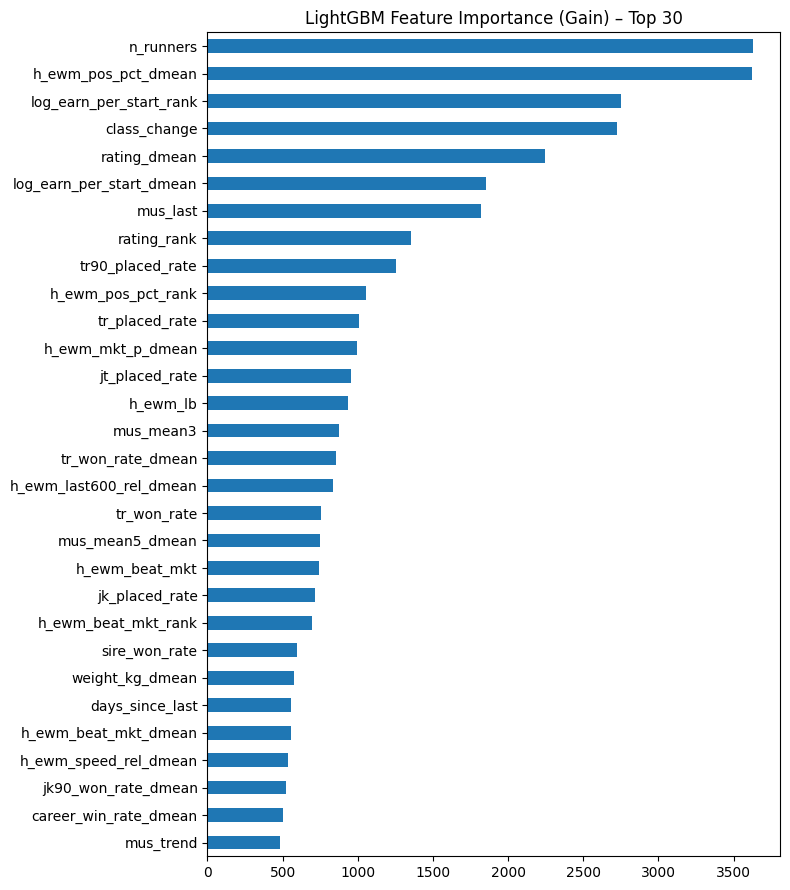

In [ ]:
imp = pd.Series(model.feature_importance("gain"), index=FEATURES).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 9))
imp.head(30)[::-1].plot.barh(ax=ax)
ax.set_title("LightGBM Feature Importance (Gain) – Top 30")
plt.tight_layout(); plt.show()

### 5.4 Leak-Test: Label-Shuffle
Sieger werden *innerhalb jedes Rennens* zufällig neu verteilt (5 Wiederholungen). Modelle darauf dürfen auf Validation
im Mittel nicht besser sein als der Zufall (Top-1 ≈ Ø 1/Feldgröße). Wären sie es, gäbe es eine Struktur-Leckage
(z. B. über IDs, Startnummern-Reihenfolge oder Duplikate).

In [ ]:
N_SHUFFLES = 5
V = D[D.split == "valid"].copy()
exp_top1 = (1 / V.groupby("race_id")["n_runners"].first()).mean()
un = evaluate(V, "p_uniform")
sh_rows = []
for k in range(N_SHUFFLES):
    R = np.random.default_rng(100 + k)
    S = D[D.split.isin(["train", "train_es"])].copy()
    S["won"] = S.groupby("race_id")["won"].transform(lambda s: pd.Series(R.permutation(s.values), index=s.index))
    m_sh = fit_lgb(S[S.split == "train"], S[S.split == "train_es"], best_params)
    V["p_shuf"] = race_normalize(pd.Series(m_sh.predict(V[FEATURES]), index=V.index), V["race_id"])
    sh_rows.append(evaluate(V, "p_shuf"))
sh = pd.DataFrame(sh_rows)
se = np.sqrt(exp_top1 * (1 - exp_top1) / V["race_id"].nunique() / N_SHUFFLES)
print(f"Shuffle-Modelle (Ø {N_SHUFFLES}): winner_logloss={sh.winner_logloss.mean():.4f}  top1={sh.top1_hit.mean():.3f}")
print(f"Zufall:                 winner_logloss={un['winner_logloss']:.4f}  top1 erwartet={exp_top1:.3f} (±{3*se:.3f})")
assert sh.top1_hit.mean() < exp_top1 + 3 * se, "Shuffle-Modell trifft Sieger besser als Zufall -> Leak-Verdacht"
assert sh.winner_logloss.mean() > un["winner_logloss"] - 0.03, "Shuffle-Modell schlägt Zufall -> Leak-Verdacht"
print("Label-Shuffle-Test OK ✅")

Shuffle-Modelle (Ø 5): winner_logloss=2.3353  top1=0.102
Zufall:                 winner_logloss=2.3314  top1 erwartet=0.102 (±0.013)
Label-Shuffle-Test OK ✅


## 6 · Markt-Blend (Benter-Ansatz) & Kalibrierung

Der Wettmarkt ist sehr effizient. Statt ihn zu ignorieren, kombinieren wir Modell und Markt in einem
**konditionalen Logit** pro Rennen:

$$p_i = \frac{\exp(\alpha \log p^{model}_i + \beta \log p^{markt}_i)}{\sum_j \exp(\alpha \log p^{model}_j + \beta \log p^{markt}_j)}$$

α und β werden **nur auf Validation** geschätzt. Ist α ≈ 0, bringt das Modell nichts über den Markt hinaus.

In [ ]:
def fit_blend(df, cols=("p_model", "p_market")):
    L = [np.log(df[c].clip(1e-6)) for c in cols]
    rid = df["race_id"]; y = df["won"].values == 1

    def nll(w):
        s = sum(wi * li for wi, li in zip(w, L))
        return -np.log(race_softmax(s, rid).values[y]).mean()

    r = minimize(nll, x0=np.ones(len(cols)) * .5, method="Nelder-Mead")
    return r.x


def apply_blend(df, w, cols=("p_model", "p_market")):
    s = sum(wi * np.log(df[c].clip(1e-6)) for wi, c in zip(w, cols))
    return race_softmax(s, df["race_id"])


VAL = D[D.split == "valid"]
w_blend = fit_blend(VAL)
w_temp = fit_blend(VAL, cols=("p_model",))           # reine Kalibrierung (Temperatur) des Modells
print(f"Blend: α(Modell)={w_blend[0]:.3f}  β(Markt)={w_blend[1]:.3f}   |  Temperatur Modell: {w_temp[0]:.3f}")
D["p_blend"] = apply_blend(D, w_blend)
D["p_model_cal"] = apply_blend(D, w_temp, cols=("p_model",))

Blend: α(Modell)=0.601  β(Markt)=0.662   |  Temperatur Modell: 1.144


## 7 · Finale Evaluation auf dem Test-Set (Hold-out)

In [ ]:
TEST = D[D.split == "test"].copy()
ev = pd.DataFrame({m: evaluate(TEST, m) for m in ["p_uniform", "p_market", "p_logreg", "p_model_cal", "p_blend"]}).T
ev.round(4)

,winner_logloss,binary_logloss,brier,auc,top1_hit,races
p_uniform,2.2849,0.3127,0.0864,0.5966,0.1398,980.0
p_market,1.9966,0.2805,0.0795,0.7515,0.2898,980.0
p_logreg,2.0492,0.2865,0.0809,0.7290,0.2571,980.0
p_model_cal,2.0518,0.2867,0.0809,0.7285,0.2561,980.0
p_blend,1.9795,0.2786,0.0791,0.7549,0.2949,980.0


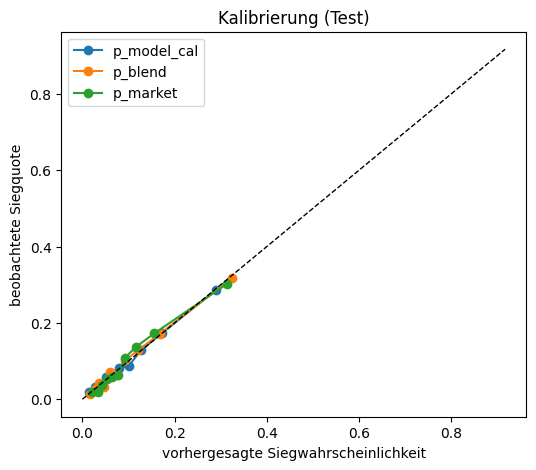

In [ ]:
def calibration_plot(df, cols, bins=10):
    fig, ax = plt.subplots(figsize=(6, 5))
    for c in cols:
        q = pd.qcut(df[c], bins, duplicates="drop")
        t = df.groupby(q, observed=True).agg(pred=(c, "mean"), obs=("won", "mean"))
        ax.plot(t.pred, t.obs, "o-", label=c)
    lim = df[cols].max().max()
    ax.plot([0, lim], [0, lim], "k--", lw=1)
    ax.set_xlabel("vorhergesagte Siegwahrscheinlichkeit"); ax.set_ylabel("beobachtete Siegquote")
    ax.set_title("Kalibrierung (Test)"); ax.legend(); plt.show()


calibration_plot(TEST, ["p_model_cal", "p_blend", "p_market"])

## 8 · Profit & Loss

**Abrechnung:** 1 € Sieg-Wette, Auszahlung = `odds_final` × Einsatz (PMU-Endquote, inkl. Einsatz). Gewinn = Quote − 1 bzw. −1.
**Entscheidung:** nur mit Informationen, die vor dem Start bekannt sind (Modell + `odds_morning`).

> Hinweis: Bei Pari-Mutuel verändert der eigene Einsatz die Quote leicht – bei 1 € vernachlässigbar.
> Die PMU-Marge (~15–20 %) sorgt dafür, dass „blindes“ Wetten im Mittel klar Geld verliert – das ist die Messlatte.

In [ ]:
def settle(df: pd.DataFrame, mask: pd.Series, odds_col=SETTLE_ODDS) -> pd.DataFrame:
    b = df[mask & df[odds_col].notna()].copy()
    b["stake"] = STAKE
    b["pnl"] = np.where(b["won"] == 1, (b[odds_col] - 1) * STAKE, -STAKE)
    return b.sort_values(["date", "post_dt", "race_id"])


def max_drawdown(pnl: pd.Series) -> float:
    c = pnl.cumsum()
    return float((c.cummax() - c).max()) if len(c) else 0.0


def longest_losing_streak(pnl: pd.Series) -> int:
    best = cur = 0
    for x in pnl:
        cur = cur + 1 if x < 0 else 0
        best = max(best, cur)
    return best


def bootstrap_roi(b: pd.DataFrame, n=2000) -> tuple:
    """Block-Bootstrap über Renntage (Wetten eines Tages sind korreliert)."""
    if b.empty:
        return (np.nan, np.nan, np.nan)
    daily = b.groupby("date").agg(pnl=("pnl", "sum"), stake=("stake", "sum"))
    idx = RNG.integers(0, len(daily), (n, len(daily)))
    rois = daily["pnl"].values[idx].sum(1) / daily["stake"].values[idx].sum(1)
    return (np.percentile(rois, 2.5), np.percentile(rois, 97.5), (rois > 0).mean())


def pnl_summary(b: pd.DataFrame, name: str) -> dict:
    lo, hi, p_pos = bootstrap_roi(b)
    return {"Strategie": name, "Wetten": len(b), "Treffer": int(b["won"].sum()),
            "Trefferquote": b["won"].mean() if len(b) else np.nan,
            "Ø Quote": b[SETTLE_ODDS].mean() if len(b) else np.nan,
            "Einsatz €": b["stake"].sum(), "Gewinn €": b["pnl"].sum(),
            "ROI": b["pnl"].sum() / b["stake"].sum() if len(b) else np.nan,
            "ROI 95%-KI": f"[{lo:+.1%}, {hi:+.1%}]", "P(ROI>0)": p_pos,
            "Max Drawdown €": max_drawdown(b["pnl"]), "längste Verlustserie": longest_losing_streak(b["pnl"])}


def top_pick_mask(df, pcol):
    return df.index.isin(df.groupby("race_id")[pcol].idxmax())


def value_mask(df, pcol, min_edge, min_p, max_odds, odds_col=DECISION_ODDS):
    ev = df[pcol] * df[odds_col] - 1
    return (ev > min_edge) & (df[pcol] >= min_p) & (df[odds_col] <= max_odds)

### 8.1 Value-Regel auf **Validation** wählen
Grid über Mindest-Edge, Mindest-Wahrscheinlichkeit und Maximalquote. Gewählt wird nur, was auf Validation
mindestens `MIN_BETS_FOR_SELECTION` Wetten hat. Die Heatmap zeigt, ob der Bereich stabil ist oder nur ein Zufallstreffer.

gewählte Value-Regel (Validation): {'pcol': 'p_blend', 'min_edge': 0.5, 'min_p': 0.05, 'max_odds': 20, 'n': 107, 'roi': 0.09999999999999995}


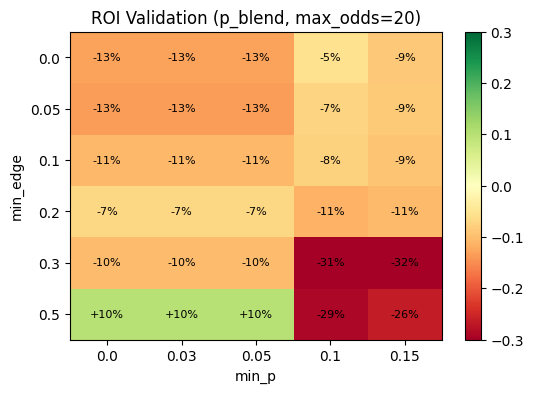

In [ ]:
VAL = D[D.split == "valid"].copy()
rows = []
for pcol in ["p_blend", "p_model_cal"]:
    for me in [0.0, 0.05, 0.10, 0.20, 0.30, 0.50]:
        for mp in [0.0, 0.03, 0.05, 0.10, 0.15]:
            for mo in [10, 20, 50]:
                b = settle(VAL, value_mask(VAL, pcol, me, mp, mo))
                rows.append(dict(pcol=pcol, min_edge=me, min_p=mp, max_odds=mo, n=len(b),
                                 roi=b.pnl.sum() / max(len(b), 1)))
grid_val = pd.DataFrame(rows)
cand = grid_val[grid_val.n >= MIN_BETS_FOR_SELECTION].sort_values("roi", ascending=False)
best_rule = cand.iloc[0].to_dict() if len(cand) else dict(pcol="p_blend", **WF_RULE)
print("gewählte Value-Regel (Validation):", best_rule)
piv = grid_val[(grid_val.pcol == best_rule["pcol"]) & (grid_val.max_odds == best_rule["max_odds"])] \
    .pivot(index="min_edge", columns="min_p", values="roi")
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(piv.values, cmap="RdYlGn", vmin=-.3, vmax=.3, aspect="auto")
ax.set_xticks(range(len(piv.columns)), piv.columns); ax.set_yticks(range(len(piv.index)), piv.index)
ax.set_xlabel("min_p"); ax.set_ylabel("min_edge"); ax.set_title(f"ROI Validation ({best_rule['pcol']}, max_odds={best_rule['max_odds']})")
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        ax.text(j, i, f"{piv.values[i, j]:+.0%}", ha="center", va="center", fontsize=8)
plt.colorbar(im); plt.show()

### 8.2 P&L auf dem **Test-Set** (einmalige Auswertung)

In [ ]:
TEST = D[D.split == "test"].copy()
strategies = {
    "Top-Pick Modell": top_pick_mask(TEST, "p_model_cal"),
    "Top-Pick Blend": top_pick_mask(TEST, "p_blend"),
    "Favorit (Morgenquote) – Benchmark": top_pick_mask(TEST, "p_market"),
    f"Value ({best_rule['pcol']}, edge>{best_rule['min_edge']}, p>={best_rule['min_p']}, odds<={best_rule['max_odds']})":
        value_mask(TEST, best_rule["pcol"], best_rule["min_edge"], best_rule["min_p"], best_rule["max_odds"]),
    f"Value vorab fixiert {WF_RULE}": value_mask(TEST, "p_blend", **WF_RULE),
}
bets = {k: settle(TEST, pd.Series(v, index=TEST.index)) for k, v in strategies.items()}
pnl_table = pd.DataFrame([pnl_summary(b, k) for k, b in bets.items()]).set_index("Strategie")

# Zufalls-Benchmark: je Rennen ein zufälliges Pferd, 1000 Simulationen
rand_roi = []
for _ in range(1000):
    pick = TEST.groupby("race_id").sample(1, random_state=int(RNG.integers(1e9))).index
    b = settle(TEST, TEST.index.isin(pick))
    rand_roi.append(b.pnl.sum() / len(b))
print(f"Zufallswetten ROI: Median {np.median(rand_roi):+.1%}  (5–95 %: {np.percentile(rand_roi, 5):+.1%} … {np.percentile(rand_roi, 95):+.1%})")
pnl_table.style.format({"Trefferquote": "{:.1%}", "Ø Quote": "{:.2f}", "Einsatz €": "{:.0f}", "Gewinn €": "{:+.2f}",
                        "ROI": "{:+.1%}", "P(ROI>0)": "{:.0%}", "Max Drawdown €": "{:.1f}"})

Zufallswetten ROI: Median -23.3%  (5–95 %: -40.6% … -3.1%)


,Wetten,Treffer,Trefferquote,Ø Quote,Einsatz €,Gewinn €,ROI,ROI 95%-KI,P(ROI>0),Max Drawdown €,längste Verlustserie
Strategie,,,,,,,,,,,
Top-Pick Modell,980,251,25.6%,4.70,980,-139.10,-14.2%,"[-26.4%, -1.2%]",2%,148.7,37
Top-Pick Blend,980,289,29.5%,3.71,980,-110.30,-11.3%,"[-21.0%, -0.9%]",2%,126.4,18
Favorit (Morgenquote) – Benchmark,980,284,29.0%,3.86,980,-127.20,-13.0%,"[-22.6%, -3.1%]",0%,144.8,21
"Value (p_blend, edge>0.5, p>=0.05, odds<=20)",101,16,15.8%,7.57,101,-7.30,-7.2%,"[-48.3%, +33.9%]",34%,24.3,14
"Value vorab fixiert {'min_edge': 0.1, 'min_p': 0.05, 'max_odds': 25.0}",1200,159,13.2%,9.56,1200,-190.70,-15.9%,"[-31.2%, -0.6%]",2%,200.4,34


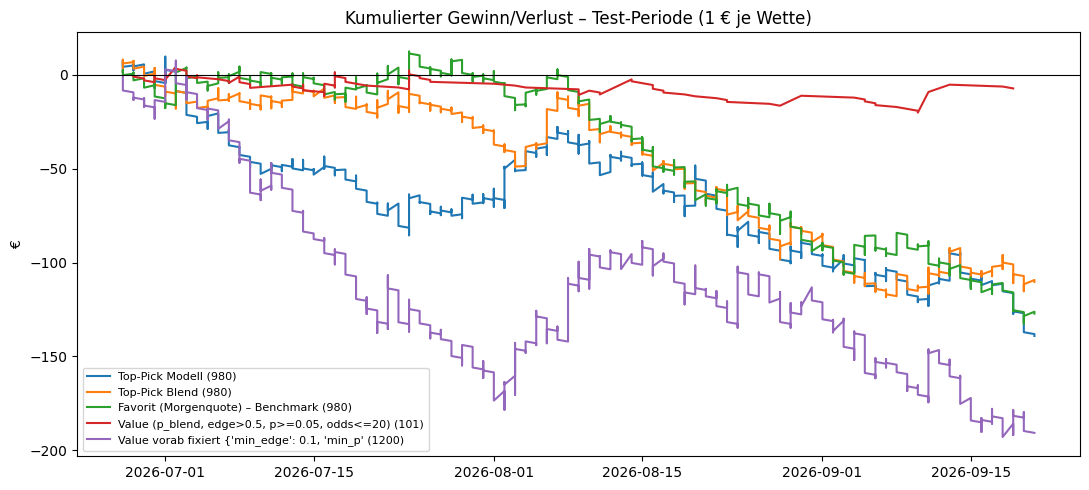

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
for k, b in bets.items():
    if len(b):
        ax.plot(b["date"].values, b["pnl"].cumsum().values, label=f"{k[:45]} ({len(b)})")
ax.axhline(0, color="k", lw=.8)
ax.set_title("Kumulierter Gewinn/Verlust – Test-Periode (1 € je Wette)")
ax.set_ylabel("€"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

### 8.3 Aufschlüsselung: Monat & Quotenband

In [ ]:
main_key = list(bets)[3]
b = bets[main_key].copy()
if len(b):
    b["Monat"] = b["date"].dt.to_period("M")
    b["Quotenband"] = pd.cut(b[SETTLE_ODDS], [1, 3, 5, 10, 20, 1000])
    display(b.groupby("Monat").agg(Wetten=("pnl", "size"), Gewinn=("pnl", "sum"), Treffer=("won", "sum"))
            .assign(ROI=lambda t: t.Gewinn / t.Wetten))
    display(b.groupby("Quotenband", observed=True).agg(Wetten=("pnl", "size"), Gewinn=("pnl", "sum"),
                                                      Treffer=("won", "sum")).assign(ROI=lambda t: t.Gewinn / t.Wetten))
for k in ["Top-Pick Blend"]:
    bb = bets[k].copy(); bb["Quotenband"] = pd.cut(bb[SETTLE_ODDS], [1, 2, 3, 5, 10, 1000])
    display(bb.groupby("Quotenband", observed=True).agg(Wetten=("pnl", "size"), Gewinn=("pnl", "sum"),
                                                       Treffer=("won", "sum")).assign(ROI=lambda t: t.Gewinn / t.Wetten))

,Wetten,Gewinn,Treffer,ROI
Monat,,,,
2026-06,6,-1.9,1,-0.316667
2026-07,56,-1.9,10,-0.033929
2026-08,26,-7.4,3,-0.284615
2026-09,13,3.9,2,0.300000


,Wetten,Gewinn,Treffer,ROI
Quotenband,,,,
"(1, 3]",12,-1.8,4,-0.150000
"(3, 5]",24,-3.0,5,-0.125000
"(5, 10]",48,-8.5,5,-0.177083
"(10, 20]",14,9.0,2,0.642857
"(20, 1000]",3,-3.0,0,-1.000000


,Wetten,Gewinn,Treffer,ROI
Quotenband,,,,
"(1, 2]",160,-17.1,87,-0.106875
"(2, 3]",247,-23.7,89,-0.095951
"(3, 5]",396,-50.0,88,-0.126263
"(5, 10]",171,-24.5,24,-0.143275
"(10, 1000]",6,5.0,1,0.833333


## 9 · Walk-Forward-Backtest (robusteste Schätzung)

Realistischer als ein einzelner Split: **jeden Monat neu trainieren** mit allen Daten davor, dann den Folgemonat
vorhersagen. Der Markt-Blend wird nur aus den Out-of-Sample-Vorhersagen der **Vormonate** geschätzt
(der erste OOS-Monat ist deshalb reiner Burn-in), die Value-Regel ist vorab fixiert (`WF_RULE`).
Damit enthält kein Monat Information aus seiner eigenen Zukunft.

In [ ]:
ALL = X[(X["valid_train"] == True)].copy()
ALL = ALL[ALL["date"] >= pd.Timestamp(days[0])]
ALL["p_market"] = race_normalize(ALL["mkt_prob_morning"].fillna(1 / ALL["n_runners"]), ALL["race_id"])
months = ALL["date"].dt.to_period("M").sort_values().unique()
MIN_TRAIN_MONTHS = 2
oos = []
for mth in months[MIN_TRAIN_MONTHS:]:
    start = mth.start_time
    trn = ALL[ALL["date"] < start]
    tst = ALL[ALL["date"].dt.to_period("M") == mth].copy()
    if trn["race_id"].nunique() < 300 or tst.empty:
        continue
    cut = date_quantile(trn["date"], .85)
    m = fit_lgb(trn[trn.date < cut], trn[trn.date >= cut], best_params)
    tst["p_model"] = race_normalize(pd.Series(m.predict(tst[FEATURES], num_iteration=m.best_iteration), index=tst.index),
                                    tst["race_id"])
    prev = pd.concat(oos) if oos else pd.DataFrame()
    if len(prev) and prev["race_id"].nunique() >= 200:
        w = fit_blend(prev)
        tst["p_blend"] = apply_blend(tst, w)
        tst["blend_ready"] = True
    else:                      # erster OOS-Monat: dient nur zur Blend-Schätzung, fließt NICHT in die P&L ein
        w = (np.nan, np.nan)
        tst["p_blend"] = tst["p_model"]
        tst["blend_ready"] = False
    tst["blend_a"], tst["blend_b"] = w[0], w[1]
    oos.append(tst)
    print(f"{mth}: train races={trn.race_id.nunique():5d}  test races={tst.race_id.nunique():4d}  α={w[0]:.2f} β={w[1]:.2f}")
WF = pd.concat(oos) if oos else pd.DataFrame()
if len(WF):
    print("Burn-in-Monate (nur Blend-Kalibrierung):", sorted(WF.loc[~WF.blend_ready, "date"].dt.to_period("M").astype(str).unique()))
    WF = WF[WF["blend_ready"]].copy()

2025-09: train races=  688  test races= 359  α=nan β=nan
2025-10: train races= 1047  test races= 374  α=0.29 β=1.04
2025-11: train races= 1421  test races= 376  α=0.38 β=0.88
2025-12: train races= 1797  test races= 244  α=0.51 β=0.79
2026-01: train races= 2041  test races= 249  α=0.49 β=0.81
2026-02: train races= 2290  test races= 245  α=0.48 β=0.80
2026-03: train races= 2535  test races= 314  α=0.48 β=0.82
2026-04: train races= 2849  test races= 345  α=0.49 β=0.81
2026-05: train races= 3194  test races= 366  α=0.48 β=0.81
2026-06: train races= 3560  test races= 322  α=0.51 β=0.78
2026-07: train races= 3882  test races= 346  α=0.53 β=0.76
2026-08: train races= 4228  test races= 365  α=0.51 β=0.77
2026-09: train races= 4593  test races= 236  α=0.52 β=0.76
Burn-in-Monate (nur Blend-Kalibrierung): ['2025-09']


,Wetten,Treffer,Trefferquote,Ø Quote,Einsatz €,Gewinn €,ROI,ROI 95%-KI,P(ROI>0),Max Drawdown €,längste Verlustserie
Strategie,,,,,,,,,,,
WF Top-Pick Modell,3780,945,25.0%,5.05,3780,-314.40,-8.3%,"[-14.9%, -1.6%]",1%,319.0,34
WF Top-Pick Blend,3780,1041,27.5%,3.92,3780,-476.90,-12.6%,"[-17.7%, -7.2%]",0%,481.5,21
WF Favorit (Benchmark),3779,1020,27.0%,4.08,3779,-493.10,-13.0%,"[-18.1%, -7.9%]",0%,497.7,21
"WF Value {'min_edge': 0.1, 'min_p': 0.05, 'max_odds': 25.0}",2444,392,16.0%,8.02,2444,-265.20,-10.9%,"[-19.7%, -1.2%]",2%,270.7,28


,winner_logloss,binary_logloss,brier,auc,top1_hit,races
p_market,2.0778,0.2717,0.0761,0.7432,0.2697,3782.0
p_model,2.1187,0.2761,0.0772,0.7262,0.2499,3782.0
p_blend,2.0537,0.2693,0.0758,0.7506,0.2753,3782.0


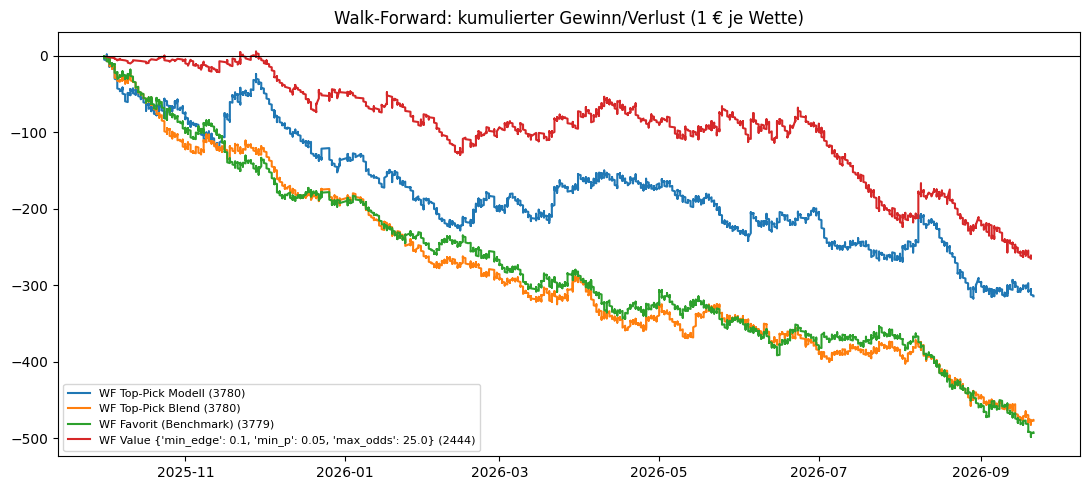

WF Top-Pick Modell       WF Top-Pick Blend        WF Favorit (Benchmark)       WF Value {'min_edge': 0.1, 'min_p': 0.05, 'max_odds': 25.0}       
                      size   sum              size    sum                   size   sum                                                        size    sum
date                                                                                                                                                     
2025-10                374 -74.9               374 -118.6                    373 -94.8                                                 44            -6.9
2025-11                376  33.1               376   -2.9                    376 -41.9                                                132             1.3
2025-12                244 -94.7               244  -67.1                    244 -55.8                                                162           -41.9
2026-01                249 -50.2               249  -73.3                    249 -52.3                                                134           -28.9
2026-02                245 -11.6               245  -22.7                    245 -21.1                                                154           -22.3
2026-03                314  43.3               314   -5.3                    314 -21.1                                                177            26.3
2026-04                343 -13.6               343  -51.3                    343 -37.1                                                249           -14.2
2026-05                366 -60.2               366   -4.9                    366 -23.4                                                237            -1.1
2026-06                322  24.0               322  -37.7                    322 -30.0                                                304            -7.8
2026-07                346 -59.0               346   -0.0                    346   9.7                                                326          -112.2
2026-08                365 -31.6               365  -64.5                    365 -92.0                                                317            -7.1
2026-09                236 -19.0               236  -28.6                    236 -33.3                                                208           -50.4

In [ ]:
if len(WF):
    wf_bets = {"WF Top-Pick Modell": settle(WF, top_pick_mask(WF, "p_model")),
               "WF Top-Pick Blend": settle(WF, top_pick_mask(WF, "p_blend")),
               "WF Favorit (Benchmark)": settle(WF, top_pick_mask(WF, "p_market")),
               f"WF Value {WF_RULE}": settle(WF, value_mask(WF, "p_blend", **WF_RULE))}
    display(pd.DataFrame([pnl_summary(b, k) for k, b in wf_bets.items()]).set_index("Strategie")
            .style.format({"Trefferquote": "{:.1%}", "Ø Quote": "{:.2f}", "Einsatz €": "{:.0f}", "Gewinn €": "{:+.2f}",
                           "ROI": "{:+.1%}", "P(ROI>0)": "{:.0%}", "Max Drawdown €": "{:.1f}"}))
    display(pd.DataFrame({m: evaluate(WF, m) for m in ["p_market", "p_model", "p_blend"]}).T.round(4))
    fig, ax = plt.subplots(figsize=(11, 5))
    for k, b in wf_bets.items():
        ax.plot(b["date"].values, b["pnl"].cumsum().values, label=f"{k} ({len(b)})")
    ax.axhline(0, color="k", lw=.8); ax.legend(fontsize=8)
    ax.set_title("Walk-Forward: kumulierter Gewinn/Verlust (1 € je Wette)"); plt.tight_layout(); plt.show()
    mon = pd.concat({k: b.groupby(b["date"].dt.to_period("M"))["pnl"].agg(["size", "sum"]) for k, b in wf_bets.items()}, axis=1)
    display(mon.round(2))

## 10 · Vorhersage für kommende Rennen
Liegen für einen Tag bereits `pmu_races`/`pmu_runners` **ohne Ergebnis** im Ordner (Programm des Tages),
werden hier Siegwahrscheinlichkeiten und Value-Kandidaten ausgegeben. Die Features dieser Zeilen basieren
automatisch nur auf Rennen vor diesem Tag.

In [ ]:
final_model = model   # validiertes Modell; für den Live-Einsatz optional mit denselben Parametern auf allen Daten neu trainieren
UP = X[~X["has_result"]].copy()
if len(UP):
    UP["p_model"] = race_normalize(pd.Series(final_model.predict(UP[FEATURES], num_iteration=final_model.best_iteration),
                                             index=UP.index), UP["race_id"])
    UP["p_market"] = race_normalize(UP["mkt_prob_morning"].fillna(1 / UP["n_runners"]), UP["race_id"])
    UP["p_blend"] = apply_blend(UP, w_blend)
    UP["fair_odds"] = 1 / UP["p_blend"]
    UP["edge"] = UP["p_blend"] * UP[DECISION_ODDS] - 1
    UP["value_bet"] = value_mask(UP, best_rule["pcol"] if best_rule["pcol"] in UP else "p_blend",
                                 best_rule["min_edge"], best_rule["min_p"], best_rule["max_odds"])
    cols = ["race_id", "saddle_no", "horse", "odds_morning", "p_model", "p_market", "p_blend", "fair_odds", "edge", "value_bet"]
    display(UP.sort_values(["race_id", "p_blend"], ascending=[True, False])[cols].round(3))
else:
    print("Keine Rennen ohne Ergebnis im Datensatz – zum Live-Einsatz das Tagesprogramm in den Ordner legen.")

,race_id,saddle_no,horse,odds_morning,p_model,p_market,p_blend,fair_odds,edge,value_bet
46824,20260625R1C1,1,NALON RIVER,NaN,0.382,0.200,0.308,3.249,NaN,False
46828,20260625R1C1,5,DISSEMBLE,NaN,0.287,0.200,0.259,3.855,NaN,False
46826,20260625R1C1,3,MASCIA MAGIQUE,NaN,0.158,0.200,0.181,5.528,NaN,False
46825,20260625R1C1,2,LITTORAL NORD,NaN,0.094,0.200,0.132,7.557,NaN,False
46827,20260625R1C1,4,DERBYCAT,NaN,0.079,0.200,0.120,8.365,NaN,False
...,...,...,...,...,...,...,...,...,...,...
46908,20260625R1C9,5,VIOLIN,NaN,0.045,0.067,0.055,18.311,NaN,False
46916,20260625R1C9,14,GYP SEA,NaN,0.040,0.067,0.051,19.597,NaN,False
46918,20260625R1C9,16,ATAMAK,NaN,0.027,0.067,0.040,24.756,NaN,False
46907,20260625R1C9,4,LADY WANDA,NaN,0.026,0.067,0.039,25.673,NaN,False


## 11 · Modell speichern

In [ ]:
import json
Path("model_out").mkdir(exist_ok=True)
model.save_model("model_out/lgb_winner.txt", num_iteration=model.best_iteration)
json.dump({"features": FEATURES, "cat_features": CAT_FEATURES, "blend_weights": list(map(float, w_blend)),
           "temperature": float(w_temp[0]), "value_rule": {k: (float(v) if isinstance(v, (int, float, np.floating)) else v)
                                                            for k, v in best_rule.items()},
           "params": {k: (int(v) if isinstance(v, (np.integer,)) else v) for k, v in best_params.items()},
           "career_pre_race": bool(CAREER_PRE_RACE), "form_pre_race": bool(FORM_PRE_RACE),
           "train_end": str(t_end.date()), "valid_end": str(v_end.date())},
          open("model_out/config.json", "w"), indent=2)
print("gespeichert in model_out/")

gespeichert in model_out/


## 12 · Interpretation & nächste Schritte

* **Maßstab ist der Markt, nicht der Zufall.** Ein Modell mit höherer Trefferquote als Zufall ist wertlos, wenn es den
  Favoriten nur nachbildet. Entscheidend: Ist der Winner-Log-Loss des Blends besser als der des Markts und ist α im
  Blend deutlich > 0?
* **Konfidenzintervalle ernst nehmen.** Bei einigen hundert Wetten liegt die Unsicherheit des ROI schnell bei ±20 %-Punkten.
  Nur wenn das Walk-Forward-Ergebnis über viele Monate positiv ist, ist ein Edge plausibel.
* **Entscheidungsquote:** Standard ist die Morgenquote (konservativ). Wer kurz vor dem Start wettet, kann
  `DECISION_ODDS` auf eine späte Quote setzen – aber nicht auf `odds_final`, die ist zum Wettzeitpunkt unbekannt.
* **Mögliche Erweiterungen:** Par-Zeiten je Bahn/Distanz/Boden für absolute Speed-Figures, Pace-Szenario pro Rennen
  (Anzahl früher Führpferde aus `early_pos_pct`), `tracking_obstacles` für Hindernisrennen, LambdaRank-Objective,
  Kelly-Staking mit Bruchteil-Kelly.